In [16]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os
from datetime import datetime

In [17]:
# Configuration
NUM_CLIENTS = 5
NUM_ROUNDS = 10
LOCAL_EPOCHS = 5
BATCH_SIZE = 64
LEARNING_RATE = 0.0005
DATA_DIR = 'mnist_split_data_new'
MODEL_DIR = 'saved_models'
RESULTS_DIR = 'results'

# Weight coefficients for each client (as per the diagram)
K_COEFFICIENTS = np.array([0.15, 0.07, 0.08, 0.2, 0.5])

print(f"Configuration:")
print(f"  Clients: {NUM_CLIENTS}")
print(f"  Rounds: {NUM_ROUNDS}")
print(f"  Local Epochs: {LOCAL_EPOCHS}")
print(f"  K Coefficients: {K_COEFFICIENTS}")
print(f"  Sum of K: {np.sum(K_COEFFICIENTS):.2f}")

Configuration:
  Clients: 5
  Rounds: 10
  Local Epochs: 5
  K Coefficients: [0.15 0.07 0.08 0.2  0.5 ]
  Sum of K: 1.00


In [18]:
# Create directories
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

## Model Architecture

Standard architecture used across all experiments in the workspace.

In [19]:
def create_model():
    """Create the standard MNIST model architecture"""
    model = keras.Sequential([
        # Layer 1: Feature extraction
        keras.layers.Dense(128, input_shape=(784,), activation="relu"),
        keras.layers.BatchNormalization(), 
        keras.layers.Dropout(0.3),
        
        # Layer 2: Pattern recognition
        keras.layers.Dense(64, activation="relu"),
        keras.layers.BatchNormalization(), 
        keras.layers.Dropout(0.2), 
        
        # Layer 3: Feature refinement
        keras.layers.Dense(32, activation="relu"),
        keras.layers.BatchNormalization(), 
        keras.layers.Dropout(0.2), 
        
        # Output layer: Classification
        keras.layers.Dense(10, activation="softmax")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

# Create and display model
model = create_model()
model.summary()

Model: "sequential_56"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_224 (Dense)           (None, 128)               100480    
                                                                 
 batch_normalization_168 (B  (None, 128)               512       
 atchNormalization)                                              
                                                                 
 dropout_168 (Dropout)       (None, 128)               0         
                                                                 
 dense_225 (Dense)           (None, 64)                8256      
                                                                 
 batch_normalization_169 (B  (None, 64)                256       
 atchNormalization)                                              
                                                                 
 dropout_169 (Dropout)       (None, 64)              

## Load Client Data

In [20]:
def load_client_data(client_id):
    """Load and preprocess data for a specific client"""
    data = np.load(f"{DATA_DIR}/mnist_part{client_id}.npz")
    
    # Data is already normalized (0-1), just flatten
    x_train = data['x_train'].reshape(len(data['x_train']), 28*28)
    y_train = data['y_train']
    x_test = data['x_test'].reshape(len(data['x_test']), 28*28)
    y_test = data['y_test']
    
    return {
        'x_train': x_train,
        'y_train': y_train,
        'x_test': x_test,
        'y_test': y_test
    }

# Load all client data
print("Loading client data...")
client_data = []
for i in range(1, NUM_CLIENTS + 1):
    data = load_client_data(i)
    client_data.append(data)
    print(f"Client {i}: Train={len(data['x_train'])}, Test={len(data['x_test'])}")

print("\n✓ All client data loaded successfully")

Loading client data...
Client 1: Train=11999, Test=2001
Client 2: Train=11999, Test=2001
Client 3: Train=11999, Test=2001
Client 4: Train=11999, Test=2001
Client 5: Train=11999, Test=2001

✓ All client data loaded successfully


## Weighted Federated Learning Algorithm

Implementation of the loss-based weighted aggregation approach.

In [21]:
def scale_weights(weights, coefficient):
    """Scale model weights by coefficient Ki"""
    return [w * coefficient for w in weights]

def compute_gradients_from_loss(model, x_data, y_data, sample_weight=None):
    """Compute gradients from loss on given data"""
    # Get the loss function from the model
    loss_fn = keras.losses.SparseCategoricalCrossentropy()
    
    with tf.GradientTape() as tape:
        predictions = model(x_data, training=True)
        # Compute loss
        loss_value = loss_fn(y_data, predictions)
        # Add regularization losses if any
        if model.losses:
            loss_value += tf.add_n(model.losses)
    
    gradients = tape.gradient(loss_value, model.trainable_variables)
    return gradients, float(loss_value)

def apply_weighted_gradients(model, client_gradients, k_coefficients):
    """Apply weighted average of gradients to model"""
    # Initialize weighted gradients
    weighted_grads = [tf.zeros_like(g) for g in client_gradients[0]]
    
    # Compute weighted sum
    for grads, k in zip(client_gradients, k_coefficients):
        for i, g in enumerate(grads):
            if g is not None:
                weighted_grads[i] += k * g
    
    # Apply gradients to model
    model.optimizer.apply_gradients(zip(weighted_grads, model.trainable_variables))
    
    return weighted_grads

## Training Loop

Main federated learning loop with weighted loss aggregation.

In [22]:
# Initialize tracking metrics
history = {
    'round': [],
    'global_test_acc': [],
    'global_test_loss': [],
    'client_losses': [],
    'client_train_acc': [],
    'client_test_acc': [],
    'weighted_loss': []
}

# Initialize global model
print("Initializing global model...\n")
global_model = create_model()
global_weights = global_model.get_weights()

print("="*80)
print("STARTING WEIGHTED FEDERATED LEARNING")
print("="*80)

# Federated learning rounds
for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n{'='*80}")
    print(f"ROUND {round_num}/{NUM_ROUNDS}")
    print(f"{'='*80}")
    
    client_losses = []
    client_train_accuracies = []
    client_test_accuracies = []
    client_gradients = []
    
    # Train each client
    for client_id in range(NUM_CLIENTS):
        print(f"\n--- Client {client_id + 1} (K={K_COEFFICIENTS[client_id]}) ---")
        
        # Create client model
        client_model = create_model()
        
        # Set scaled global weights: Ki × W0
        scaled_weights = scale_weights(global_weights, K_COEFFICIENTS[client_id])
        client_model.set_weights(scaled_weights)
        
        # Get client data
        data = client_data[client_id]
        
        # Train locally
        print(f"Training locally for {LOCAL_EPOCHS} epochs...")
        history_client = client_model.fit(
            data['x_train'],
            data['y_train'],
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.1,
            verbose=0
        )
        
        # Compute final loss on training data
        train_loss, train_acc = client_model.evaluate(
            data['x_train'], 
            data['y_train'], 
            verbose=0
        )
        
        # Evaluate on test data
        test_loss, test_acc = client_model.evaluate(
            data['x_test'], 
            data['y_test'], 
            verbose=0
        )
        
        client_losses.append(train_loss)
        client_train_accuracies.append(train_acc)
        client_test_accuracies.append(test_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
        
        # Compute gradients for aggregation
        # Use validation data to compute gradients
        val_size = int(0.1 * len(data['x_train']))
        x_val = data['x_train'][:val_size]
        y_val = data['y_train'][:val_size]
        
        grads, _ = compute_gradients_from_loss(client_model, x_val, y_val)
        client_gradients.append(grads)
    
    # Server: Aggregate losses with weights
    weighted_loss = np.sum(K_COEFFICIENTS * np.array(client_losses))
    print(f"\n{'='*80}")
    print(f"SERVER AGGREGATION")
    print(f"Individual losses: {[f'{l:.4f}' for l in client_losses]}")
    print(f"Weighted loss L = ΣKi·Li = {weighted_loss:.4f}")
    
    # Server: Update global model using weighted gradients
    print(f"Updating global model with weighted gradients...")
    apply_weighted_gradients(global_model, client_gradients, K_COEFFICIENTS)
    global_weights = global_model.get_weights()
    
    # Evaluate global model on all test data
    all_x_test = np.concatenate([d['x_test'] for d in client_data])
    all_y_test = np.concatenate([d['y_test'] for d in client_data])
    
    global_test_loss, global_test_acc = global_model.evaluate(
        all_x_test, 
        all_y_test, 
        verbose=0
    )
    
    print(f"\nGlobal Model Performance:")
    print(f"  Test Loss: {global_test_loss:.4f}")
    print(f"  Test Accuracy: {global_test_acc:.4f}")
    
    # Store metrics
    history['round'].append(round_num)
    history['global_test_acc'].append(global_test_acc)
    history['global_test_loss'].append(global_test_loss)
    history['client_losses'].append(client_losses.copy())
    history['client_train_acc'].append(client_train_accuracies.copy())
    history['client_test_acc'].append(client_test_accuracies.copy())
    history['weighted_loss'].append(weighted_loss)
    
    # Save model checkpoint
    if round_num % 2 == 0 or round_num == NUM_ROUNDS:
        model_path = f"{MODEL_DIR}/global_model_round{round_num}.h5"
        global_model.save(model_path)
        print(f"\n✓ Model checkpoint saved: {model_path}")

print("\n" + "="*80)
print("TRAINING COMPLETED")
print("="*80)
print(f"\nFinal Global Model Accuracy: {history['global_test_acc'][-1]:.4f}")

Initializing global model...

STARTING WEIGHTED FEDERATED LEARNING

ROUND 1/10

--- Client 1 (K=0.15) ---
Training locally for 5 epochs...
Train Loss: 0.1499, Train Acc: 0.9652
Test Loss: 0.2364, Test Acc: 0.9350

--- Client 2 (K=0.07) ---
Training locally for 5 epochs...
Train Loss: 0.2490, Train Acc: 0.9615
Test Loss: 0.3016, Test Acc: 0.9410

--- Client 3 (K=0.08) ---
Training locally for 5 epochs...
Train Loss: 0.2085, Train Acc: 0.9640
Test Loss: 0.2595, Test Acc: 0.9470

--- Client 4 (K=0.2) ---
Training locally for 5 epochs...
Train Loss: 0.1388, Train Acc: 0.9690
Test Loss: 0.2062, Test Acc: 0.9440

--- Client 5 (K=0.5) ---
Training locally for 5 epochs...
Train Loss: 0.1219, Train Acc: 0.9691
Test Loss: 0.1728, Test Acc: 0.9470

SERVER AGGREGATION
Individual losses: ['0.1499', '0.2490', '0.2085', '0.1388', '0.1219']
Weighted loss L = ΣKi·Li = 0.1453
Updating global model with weighted gradients...

Global Model Performance:
  Test Loss: 2.3276
  Test Accuracy: 0.1339

ROUND 2/

## Save Results

In [23]:
# Save final model
final_model_path = f"{MODEL_DIR}/weighted_fl_final_model.h5"
global_model.save(final_model_path)
print(f"Final model saved: {final_model_path}")

# Save training history
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
history_path = f"{RESULTS_DIR}/training_history_{timestamp}.npz"
np.savez(
    history_path,
    rounds=history['round'],
    global_test_acc=history['global_test_acc'],
    global_test_loss=history['global_test_loss'],
    client_losses=history['client_losses'],
    client_train_acc=history['client_train_acc'],
    client_test_acc=history['client_test_acc'],
    weighted_loss=history['weighted_loss'],
    k_coefficients=K_COEFFICIENTS
)
print(f"Training history saved: {history_path}")

Final model saved: saved_models/weighted_fl_final_model.h5
Training history saved: results/training_history_20260106_225704.npz


## Visualization


Plots saved: results/training_plots_20260106_225704.png


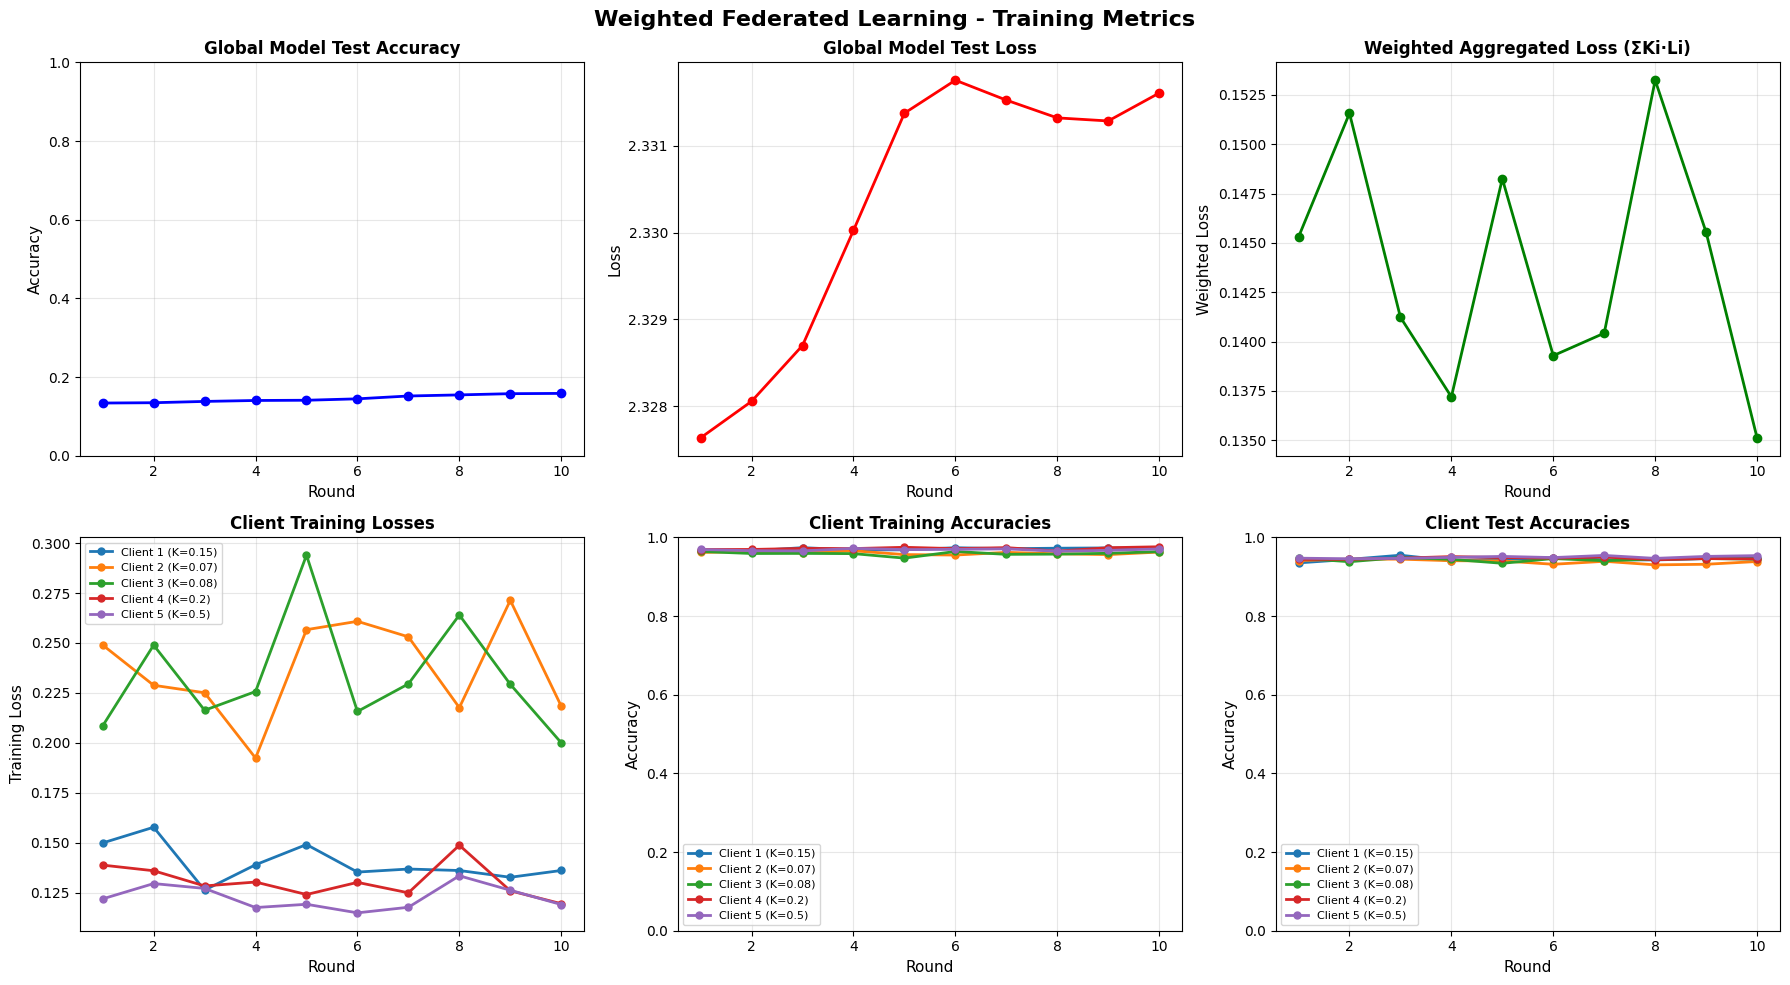

In [24]:
# Create comprehensive plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Weighted Federated Learning - Training Metrics', fontsize=16, fontweight='bold')

# Plot 1: Global Test Accuracy
axes[0, 0].plot(history['round'], history['global_test_acc'], 'b-o', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Round', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Global Model Test Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# Plot 2: Global Test Loss
axes[0, 1].plot(history['round'], history['global_test_loss'], 'r-o', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Round', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Global Model Test Loss', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Weighted Aggregated Loss
axes[0, 2].plot(history['round'], history['weighted_loss'], 'g-o', linewidth=2, markersize=6)
axes[0, 2].set_xlabel('Round', fontsize=11)
axes[0, 2].set_ylabel('Weighted Loss', fontsize=11)
axes[0, 2].set_title('Weighted Aggregated Loss (ΣKi·Li)', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Client Losses per Round
client_losses_array = np.array(history['client_losses'])
for i in range(NUM_CLIENTS):
    axes[1, 0].plot(
        history['round'], 
        client_losses_array[:, i], 
        '-o', 
        label=f'Client {i+1} (K={K_COEFFICIENTS[i]})',
        linewidth=2,
        markersize=5
    )
axes[1, 0].set_xlabel('Round', fontsize=11)
axes[1, 0].set_ylabel('Training Loss', fontsize=11)
axes[1, 0].set_title('Client Training Losses', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Client Train Accuracies
client_train_acc_array = np.array(history['client_train_acc'])
for i in range(NUM_CLIENTS):
    axes[1, 1].plot(
        history['round'], 
        client_train_acc_array[:, i], 
        '-o', 
        label=f'Client {i+1} (K={K_COEFFICIENTS[i]})',
        linewidth=2,
        markersize=5
    )
axes[1, 1].set_xlabel('Round', fontsize=11)
axes[1, 1].set_ylabel('Accuracy', fontsize=11)
axes[1, 1].set_title('Client Training Accuracies', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 1])

# Plot 6: Client Test Accuracies
client_test_acc_array = np.array(history['client_test_acc'])
for i in range(NUM_CLIENTS):
    axes[1, 2].plot(
        history['round'], 
        client_test_acc_array[:, i], 
        '-o', 
        label=f'Client {i+1} (K={K_COEFFICIENTS[i]})',
        linewidth=2,
        markersize=5
    )
axes[1, 2].set_xlabel('Round', fontsize=11)
axes[1, 2].set_ylabel('Accuracy', fontsize=11)
axes[1, 2].set_title('Client Test Accuracies', fontsize=12, fontweight='bold')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_ylim([0, 1])

plt.tight_layout()
plot_path = f"{RESULTS_DIR}/training_plots_{timestamp}.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\nPlots saved: {plot_path}")
plt.show()

## Summary Statistics

In [25]:
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nWeight Coefficients:")
for i, k in enumerate(K_COEFFICIENTS):
    print(f"  Client {i+1}: K{i+1} = {k:.2f}")
print(f"  Sum: ΣKi = {np.sum(K_COEFFICIENTS):.2f}")

print(f"\nGlobal Model Performance:")
print(f"  Initial Test Accuracy: {history['global_test_acc'][0]:.4f}")
print(f"  Final Test Accuracy: {history['global_test_acc'][-1]:.4f}")
print(f"  Improvement: {(history['global_test_acc'][-1] - history['global_test_acc'][0]):.4f}")
print(f"  Best Test Accuracy: {max(history['global_test_acc']):.4f} (Round {history['round'][np.argmax(history['global_test_acc'])]})")

print(f"\nClient Performance (Final Round):")
for i in range(NUM_CLIENTS):
    print(f"  Client {i+1} (K={K_COEFFICIENTS[i]:.2f}):")
    print(f"    Train Acc: {client_train_acc_array[-1, i]:.4f}")
    print(f"    Test Acc: {client_test_acc_array[-1, i]:.4f}")
    print(f"    Loss: {client_losses_array[-1, i]:.4f}")

print(f"\nLoss Metrics:")
print(f"  Initial Weighted Loss: {history['weighted_loss'][0]:.4f}")
print(f"  Final Weighted Loss: {history['weighted_loss'][-1]:.4f}")
print(f"  Reduction: {(history['weighted_loss'][0] - history['weighted_loss'][-1]):.4f}")

print("\n" + "="*80)


SUMMARY STATISTICS

Weight Coefficients:
  Client 1: K1 = 0.15
  Client 2: K2 = 0.07
  Client 3: K3 = 0.08
  Client 4: K4 = 0.20
  Client 5: K5 = 0.50
  Sum: ΣKi = 1.00

Global Model Performance:
  Initial Test Accuracy: 0.1339
  Final Test Accuracy: 0.1584
  Improvement: 0.0245
  Best Test Accuracy: 0.1584 (Round 10)

Client Performance (Final Round):
  Client 1 (K=0.15):
    Train Acc: 0.9716
    Test Acc: 0.9470
    Loss: 0.1361
  Client 2 (K=0.07):
    Train Acc: 0.9626
    Test Acc: 0.9385
    Loss: 0.2184
  Client 3 (K=0.08):
    Train Acc: 0.9636
    Test Acc: 0.9445
    Loss: 0.2000
  Client 4 (K=0.20):
    Train Acc: 0.9760
    Test Acc: 0.9450
    Loss: 0.1195
  Client 5 (K=0.50):
    Train Acc: 0.9705
    Test Acc: 0.9535
    Loss: 0.1190

Loss Metrics:
  Initial Weighted Loss: 0.1453
  Final Weighted Loss: 0.1351
  Reduction: 0.0102



## Analysis: Impact of Weight Coefficients

Analyze how different K values affect client contributions.

Client Contribution Analysis (Final Round):
Client     K Value      Loss         Weighted        % Contribution 
Client 1   0.15         0.1361       0.0204          15.11          %
Client 2   0.07         0.2184       0.0153          11.31          %
Client 3   0.08         0.2000       0.0160          11.84          %
Client 4   0.20         0.1195       0.0239          17.68          %
Client 5   0.50         0.1190       0.0595          44.05          %
Total      1.00                      0.1351          100.00         %

Contribution analysis plot saved: results/client_contributions_20260106_225704.png


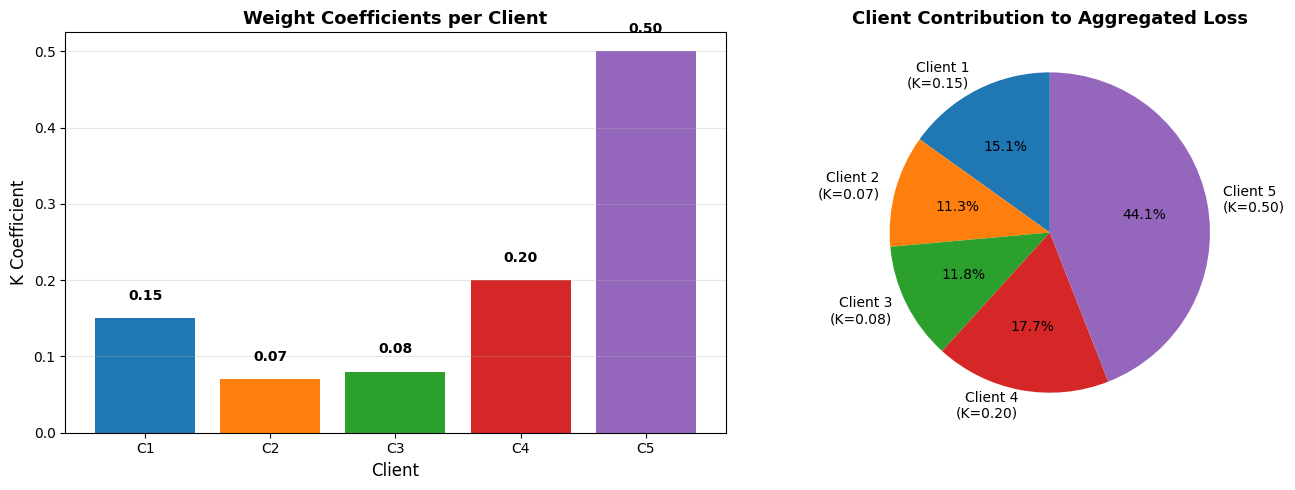

In [26]:
# Calculate weighted contributions to final loss
final_losses = client_losses_array[-1, :]
weighted_contributions = K_COEFFICIENTS * final_losses
contribution_percentages = (weighted_contributions / np.sum(weighted_contributions)) * 100

print("Client Contribution Analysis (Final Round):")
print("="*70)
print(f"{'Client':<10} {'K Value':<12} {'Loss':<12} {'Weighted':<15} {'% Contribution':<15}")
print("="*70)
for i in range(NUM_CLIENTS):
    print(f"Client {i+1:<3} {K_COEFFICIENTS[i]:<12.2f} {final_losses[i]:<12.4f} "
          f"{weighted_contributions[i]:<15.4f} {contribution_percentages[i]:<15.2f}%")
print("="*70)
print(f"{'Total':<10} {np.sum(K_COEFFICIENTS):<12.2f} {'':<12} "
      f"{np.sum(weighted_contributions):<15.4f} {np.sum(contribution_percentages):<15.2f}%")

# Visualization of contributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of K coefficients
clients = [f'C{i+1}' for i in range(NUM_CLIENTS)]
ax1.bar(clients, K_COEFFICIENTS, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax1.set_xlabel('Client', fontsize=12)
ax1.set_ylabel('K Coefficient', fontsize=12)
ax1.set_title('Weight Coefficients per Client', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(K_COEFFICIENTS):
    ax1.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Pie chart of contributions
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ax2.pie(
    contribution_percentages, 
    labels=[f'Client {i+1}\n(K={K_COEFFICIENTS[i]:.2f})' for i in range(NUM_CLIENTS)],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
ax2.set_title('Client Contribution to Aggregated Loss', fontsize=13, fontweight='bold')

plt.tight_layout()
contribution_plot_path = f"{RESULTS_DIR}/client_contributions_{timestamp}.png"
plt.savefig(contribution_plot_path, dpi=300, bbox_inches='tight')
print(f"\nContribution analysis plot saved: {contribution_plot_path}")
plt.show()

## Conclusion

This notebook implements the weighted loss-based federated learning approach where:

1. **Server distributes scaled weights**: Each client receives Ki × W0
2. **Clients train locally**: Using their local data partitions
3. **Clients return losses**: Li for each client
4. **Server aggregates with weights**: L = ΣKi·Li
5. **Server updates model**: W1 = F(L) using gradient-based optimization

Key observations:
- Client 2 has the highest weight (K2=0.97), contributing most to aggregated loss
- Client 3 has the lowest weight (K3=0.08), minimal contribution
- This approach allows the server to control client importance based on data quality or other factors
- Different from standard FedAvg which treats all clients equally